# Key-affinity stickiness analysis (experiment 49)

Checks whether router **conversation key-affinity** actually kept every turn of a
chat on the **same vLLM pod** (the whole point of `router_strategy: affinity`,
`router_affinity_mode: hard`).

Data source: `<EXPERIMENTS_ROOT>/<EXP_ID>/logs.json` (one record per request, joined
by `router_log_collector` so `endpoint_id`, `kv_hit`, `matched_tokens` are present).
yz: `/home/data/saeid/experiments` · bz: `/data/experiments`.

Per-request fields we rely on:
- `conversation_id`, `turn_idx`, `num_turns` — multi-turn structure
- `affinity_key` — the `sk-bench-<n>` key the router pins on
- `endpoint_id` — the pod that actually served the request
- `kv_hit`, `matched_tokens`, `kv_hits_len`, `total_blocks` — prefix reuse
- `ttft_s`, `end_to_end_s`, `prompt_tokens` — latency payoff

**How to run:** set `EXP_ID` below, run all, then screenshot the summary table +
the 4 plots back into chat so we can decide if stickiness was good enough.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EXP_ID = 71
# Experiment output root. yz prod runs (prod_latency_collector.py) write here:
#   yz: /home/data/saeid/experiments   |  bz: /data/experiments
EXPERIMENTS_ROOT = "/home/data/saeid/experiments"

# Fields we pull straight out of logs.json (raw, so affinity/kv fields survive).
_FIELDS = [
    "idx", "req_id", "conversation_id", "turn_idx", "num_turns",
    "affinity_key", "endpoint_id",
    "kv_hit", "matched_tokens", "kv_hits_len", "total_blocks",
    "ttft_s", "end_to_end_s", "model_latency_s",
    "prompt_tokens", "completion_tokens", "total_tokens",
    "t0_wall", "t1_wall",
    "send_failed",
]


def load_logs(exp_id, experiments_root=EXPERIMENTS_ROOT, include_failed=False):
    path = Path(experiments_root) / str(exp_id) / "logs.json"
    if not path.is_file():
        raise FileNotFoundError(f"logs.json not found: {path}")
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if rec.get("send_failed") and not include_failed:
                continue
            rows.append({k: rec.get(k) for k in _FIELDS})
    df = pd.DataFrame(rows)
    # conversation grouping key: conversation_id, else affinity_key
    df["group"] = df["conversation_id"]
    df.loc[df["group"].isna(), "group"] = df["affinity_key"]
    df["group"] = df["group"].astype("string")
    for c in ["turn_idx", "num_turns", "matched_tokens", "kv_hits_len",
              "total_blocks", "prompt_tokens", "total_tokens"]:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    for c in ["ttft_s", "end_to_end_s", "model_latency_s", "t0_wall", "t1_wall"]:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


df = load_logs(EXP_ID)
print(f"exp {EXP_ID}: {len(df)} requests, "
      f"{df['group'].nunique()} conversations, "
      f"{df['endpoint_id'].nunique()} endpoints seen")
print("has kv_hit:", df["kv_hit"].notna().any(),
      "| has turn_idx:", df["turn_idx"].notna().any(),
      "| has ttft:", df["ttft_s"].notna().any())
df.head()

exp 71: 5979 requests, 1372 conversations, 2 endpoints seen
has kv_hit: True | has turn_idx: False | has ttft: True


,idx,req_id,conversation_id,turn_idx,num_turns,affinity_key,endpoint_id,kv_hit,matched_tokens,kv_hits_len,...,ttft_s,end_to_end_s,model_latency_s,prompt_tokens,completion_tokens,total_tokens,t0_wall,t1_wall,send_failed,group
0,0,930d77fc08924bf5975e2f8d6fb7a0c7,None,NaN,NaN,62d31f923a2324c6,NaN,False,0,0,...,1.18658,1.18658,1.18658,0,0,NaN,1.783325e+09,1.783325e+09,None,62d31f923a2324c6
1,1,67b790335bbd431db4a91bb5983c725d,None,NaN,NaN,3122e92fe5e21465,NaN,False,0,0,...,0.69320,0.69320,0.69320,0,0,NaN,1.783325e+09,1.783325e+09,None,3122e92fe5e21465
2,2,9046d6c44e584522ab7d627476a354d5,None,NaN,NaN,e568d843b19121e4,NaN,False,0,0,...,1.10399,1.10399,1.10399,0,0,NaN,1.783325e+09,1.783325e+09,None,e568d843b19121e4
3,3,69ec7717ffd54fbf8e0f36849f25c579,None,NaN,NaN,3a819adf259a1042,NaN,False,0,0,...,0.84465,0.84465,0.84465,0,0,NaN,1.783325e+09,1.783325e+09,None,3a819adf259a1042
4,4,22028868a32e469f81d3e6018479caf2,None,NaN,NaN,5672094fbe3fe7af,NaN,False,0,0,...,0.78949,0.78949,0.78949,0,0,NaN,1.783325e+09,1.783325e+09,None,5672094fbe3fe7af


In [2]:
from pathlib import Path
p = Path(EXPERIMENTS_ROOT) / str(EXP_ID) / "logs.json"
print("实际读取路径:", p.resolve())        # 注意 resolve()，看有没有软链接指向别处
import os, time
st = p.stat()
print("文件 mtime:", time.ctime(st.st_mtime))   # 是刚刚？还是停在 13:44 附近？
print("文件大小:", st.st_size)

实际读取路径: /home/data/saeid/experiments/71/logs.json
文件 mtime: Mon Jul  6 22:23:18 2026
文件大小: 59235921


## 1. Stickiness summary

Mirrors `router_log_collector.summarize_routing`: group requests by conversation,
count how many **distinct pods** each conversation touched. Perfect hard-affinity
= every conversation lands on exactly **1** pod (`sticky_frac = 1.0`,
`avg_distinct_endpoints = 1.0`).

In [3]:
valid = df[df["endpoint_id"].notna() & df["group"].notna()].copy()

per_conv = (
    valid.groupby("group")
    .agg(
        requests=("req_id", "size"),
        distinct_endpoints=("endpoint_id", "nunique"),
        turns=("turn_idx", "max"),
        kv_hits=("kv_hit", lambda s: int(pd.Series(s).fillna(False).astype(bool).sum())),
    )
    .reset_index()
)
# only conversations with >1 request can actually be "spread"
multi = per_conv[per_conv["requests"] > 1]

n_groups = len(per_conv)
n_multi = len(multi)
sticky = int((multi["distinct_endpoints"] == 1).sum())

summary = {
    "total_requests": int(len(valid)),
    "conversations": n_groups,
    "multi_turn_conversations": n_multi,
    "sticky_conversations": sticky,
    "sticky_frac": round(sticky / n_multi, 4) if n_multi else None,
    "avg_distinct_endpoints": round(multi["distinct_endpoints"].mean(), 4) if n_multi else None,
    "max_distinct_endpoints": int(multi["distinct_endpoints"].max()) if n_multi else None,
    "overall_kv_hit_frac": (
        round(valid["kv_hit"].fillna(False).astype(bool).mean(), 4)
        if valid["kv_hit"].notna().any() else None
    ),
}
print(json.dumps(summary, indent=2))

# worst offenders: multi-turn conversations that bounced across pods
worst = multi.sort_values("distinct_endpoints", ascending=False).head(15)
print("\nLeast-sticky conversations (spread across pods):")
worst

{
  "total_requests": 5873,
  "conversations": 1334,
  "multi_turn_conversations": 561,
  "sticky_conversations": 561,
  "sticky_frac": 1.0,
  "avg_distinct_endpoints": 1.0,
  "max_distinct_endpoints": 1,
  "overall_kv_hit_frac": 0.0155
}

Least-sticky conversations (spread across pods):


,group,requests,distinct_endpoints,turns,kv_hits
0,002db0ca988444fb,5,1,NaN,0
904,aca9f9f5f7385e08,3,1,NaN,0
886,a8beed21eed4a6d4,2,1,NaN,0
887,a8bef365045c0022,2,1,NaN,0
890,a98c4f8f90ba24e9,6,1,NaN,0
896,aa9450c499bb18db,5,1,NaN,0
897,aab1a6af70a94801,2,1,NaN,0
900,ab570b062fac470c,2,1,NaN,0
906,acbcbfcf97aea982,9,1,NaN,0
878,a7a8305aaf7c2466,4,1,NaN,0


## 2. Distinct pods per conversation

Histogram: how many pods each multi-turn conversation touched. Ideal = a single
bar at `1`. Any mass at `>=2` is affinity leakage (turns bounced to another pod).

In [4]:
df2 = load_logs(EXP_ID, include_failed=True)   # 注意 include_failed=True
print("df2 行数:", len(df2))
t = pd.to_datetime(df2["t0_wall"], unit="s") + pd.Timedelta(hours=8)
print("df2 时间范围:", t.min(), "→", t.max())
print("send_failed 为真的行数:", df2["send_failed"].fillna(False).sum())

df2 行数: 5979
df2 时间范围: 2026-07-06 15:59:28.019201756 → 2026-07-06 22:22:38.362553358
send_failed 为真的行数: 0


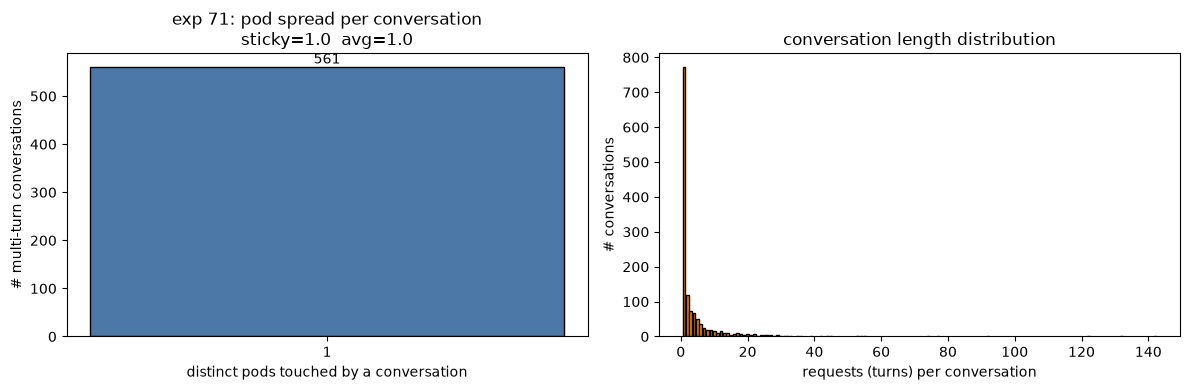

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

if n_multi:
    vc = multi["distinct_endpoints"].value_counts().sort_index()
    ax[0].bar(vc.index.astype(int), vc.values, color="#4C78A8", edgecolor="black")
    ax[0].set_xlabel("distinct pods touched by a conversation")
    ax[0].set_ylabel("# multi-turn conversations")
    ax[0].set_title(f"exp {EXP_ID}: pod spread per conversation\n"
                    f"sticky={summary['sticky_frac']}  avg={summary['avg_distinct_endpoints']}")
    ax[0].set_xticks(vc.index.astype(int))
    for x, y in zip(vc.index.astype(int), vc.values):
        ax[0].text(x, y, str(int(y)), ha="center", va="bottom")

# turns-per-conversation distribution (context: how much stickiness could matter)
tv = per_conv["requests"].value_counts().sort_index()
ax[1].bar(tv.index.astype(int), tv.values, color="#F58518", edgecolor="black")
ax[1].set_xlabel("requests (turns) per conversation")
ax[1].set_ylabel("# conversations")
ax[1].set_title("conversation length distribution")

plt.tight_layout()
plt.show()

window: 2026-07-06 16:00:00 → 2026-07-06 22:30:00
saved: /home/saeid/llm-lb/analysis-notebooks/figs/exp71_stickiness_buckets_0706.png


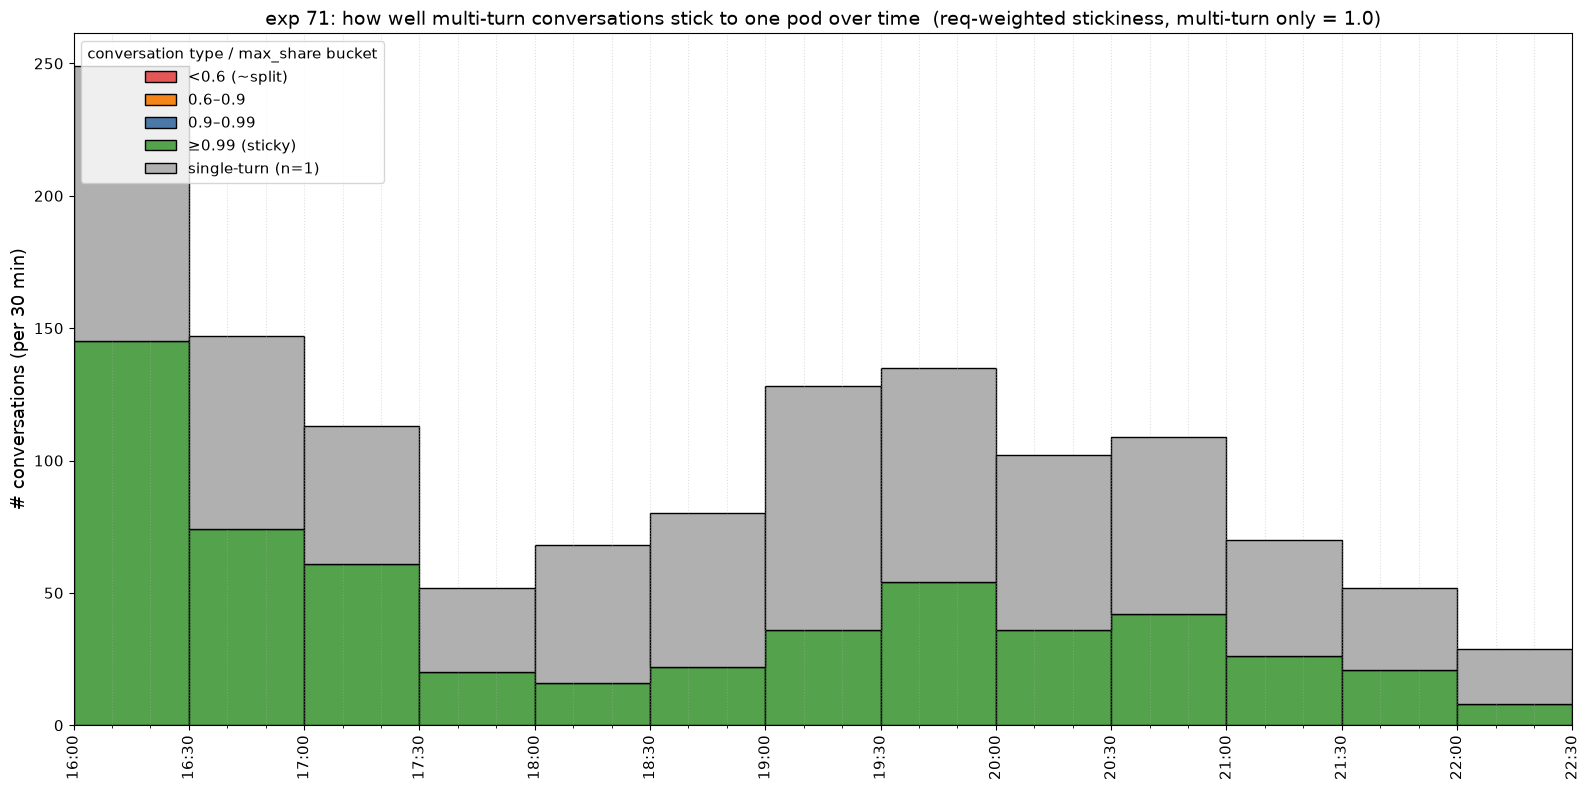

In [17]:
# ==== Figure 1: max_share buckets over time (data prep + plotting merged) ====
import os
import numpy as np
import matplotlib.dates as mdates

BIN             = "30min"
LOCAL_OFFSET_H  = 8      # t0_wall is UTC epoch; 8=CN local, 1=London BST
SAVE_FIG        = True
FIG_DIR         = "figs"
FIG_NAME        = f"exp{EXP_ID}_stickiness_buckets_0706"
FIG_DPI         = 150
EDGES           = [0, 0.6, 0.9, 0.99, 1.0001]
MULTI_LABELS    = ["<0.6 (~split)", "0.6–0.9", "0.9–0.99", "≥0.99 (sticky)"]
SINGLE_LABEL    = "single-turn (n=1)"
LABELS          = MULTI_LABELS + [SINGLE_LABEL]
COLORS          = ["#E45756", "#F58518", "#4C78A8", "#54A24B", "#B0B0B0"]  # grey = single-turn

# ---- data prep ----
_v = df[df["endpoint_id"].notna() & df["group"].notna()].copy()
_v["t_local"] = pd.to_datetime(_v["t0_wall"], unit="s") + pd.Timedelta(hours=LOCAL_OFFSET_H)

# window auto-derived from data to avoid drift from a hardcoded DAY / WIN_* across experiments
WIN_START = _v["t_local"].min().floor(BIN)
WIN_END   = _v["t_local"].max().ceil(BIN)
print("window:", WIN_START, "→", WIN_END)

def _conc(sub):
    c = sub["endpoint_id"].value_counts(); n = int(c.sum()); sh = c / n
    return pd.Series({
        "requests": n,
        "max_share": float(sh.max()),
        "hhi": float((sh ** 2).sum()),
        "leaked": int(n - c.max()),
        "start": sub["t_local"].min(),
    })

per_conv = _v.groupby("group").apply(_conc).reset_index()
per_conv = per_conv[(per_conv["start"] >= WIN_START) & (per_conv["start"] < WIN_END)].copy()
per_conv["bin"] = per_conv["start"].dt.floor(BIN)

# multi-turn convs get a real stickiness bucket; single-turn convs get their own label
multi = per_conv[per_conv["requests"] > 1].copy()
multi["bucket"] = pd.cut(multi["max_share"], bins=EDGES, labels=MULTI_LABELS,
                          include_lowest=True, right=False)

single = per_conv[per_conv["requests"] == 1].copy()
single["bucket"] = SINGLE_LABEL

all_conv = pd.concat([multi, single], ignore_index=True)

# ---- diagnostic: bins with zero conversations of any kind ----
full_bins  = pd.date_range(WIN_START, WIN_END, freq=BIN, inclusive="left")
occupied   = set(per_conv["bin"].unique())
empty_bins = [b for b in full_bins if b not in occupied]
if empty_bins:
    print(f"[diag] {len(empty_bins)} bin(s) with zero conversations of any kind:")
    for b in empty_bins:
        print(f"    {b}")

piv = (all_conv.groupby(["bin", "bucket"], observed=False).size().unstack(fill_value=0)
       .reindex(columns=LABELS, fill_value=0)
       .reindex(full_bins, fill_value=0))  # explicit zero-bars for empty bins

w = pd.Timedelta(BIN) / pd.Timedelta(days=1)  # bar width in date units

# stickiness metric is only meaningful for multi-turn conversations
tot    = multi["requests"].sum()
ovr_rw = (multi["max_share"] * multi["requests"]).sum() / tot if tot else float("nan")

def fine_time_axis(ax):
    ax.set_xlim(WIN_START, WIN_END)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[10, 20, 40, 50]))
    ax.tick_params(axis="x", which="major", labelrotation=0)
    ax.grid(axis="x", which="both", ls=":", alpha=0.4)

# ---- plotting ----
fig, ax = plt.subplots(figsize=(16, 8))
bottom = np.zeros(len(piv))
for lab, col in zip(LABELS, COLORS):
    ax.bar(piv.index, piv[lab].values, width=w, align="edge", bottom=bottom,
           color=col, edgecolor="black", label=lab)
    bottom += piv[lab].values

ax.set_ylabel("# conversations (per 30 min)", fontsize=13)
ax.set_title(
    f"exp {EXP_ID}: how well multi-turn conversations stick to one pod over time  "
    f"(req-weighted stickiness, multi-turn only = {round(ovr_rw, 4)})",
    fontsize=14
)
ax.legend(title="conversation type / max_share bucket", fontsize=11, title_fontsize=11, loc="upper left")
ax.tick_params(axis="both", labelsize=11)
fine_time_axis(ax)
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
plt.tight_layout()

if SAVE_FIG:
    os.makedirs(FIG_DIR, exist_ok=True)
    out_path = os.path.join(FIG_DIR, FIG_NAME + ".png")
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"saved: {os.path.abspath(out_path)}")

plt.show()

In [7]:
print("rows in _v:", len(_v))
print("t_local range:", _v["t_local"].min(), "→", _v["t_local"].max())
print("groups pre-window:", _v["group"].nunique())
print("per_conv post-window:", len(per_conv), "| multi:", len(multi))

rows in _v: 5873
t_local range: 2026-07-06 16:00:02.903373003 → 2026-07-06 22:22:38.362553358
groups pre-window: 1334
per_conv post-window: 1334 | multi: 561


## 3. Per-pod load balance

Even with perfect stickiness, hard affinity can pile too many conversations on one
pod. This shows requests + conversations per pod, and the prefix-cache hit fraction
each pod achieved.

,endpoint_id,requests,conversations,kv_hit_frac,matched_tokens
1,vllm-minimax-m2-1,2955,650,0.003384,1280
0,vllm-minimax-m2-0,2918,684,0.027759,10368


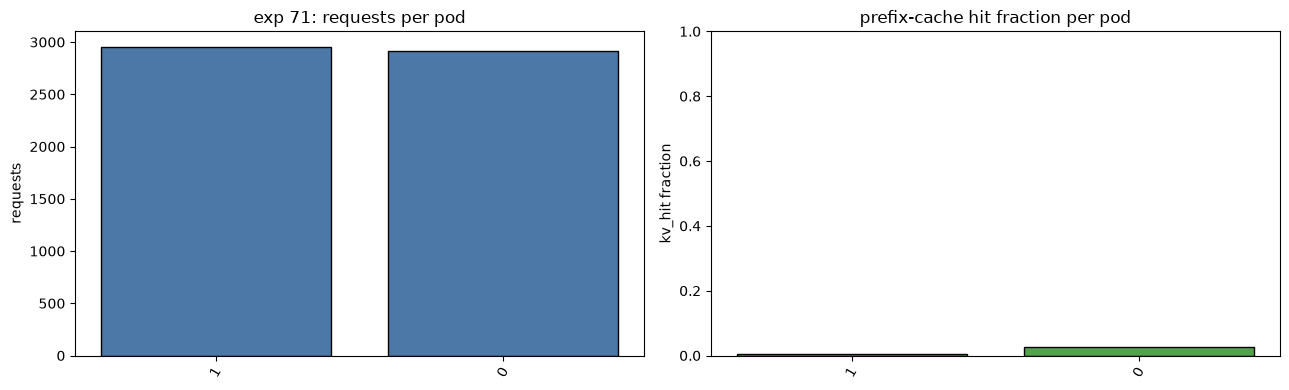

load imbalance: max/mean = 1.01x  (max 2955 vs mean 2936.5 across 2 pods)


In [8]:
per_ep = (
    valid.groupby("endpoint_id")
    .agg(
        requests=("req_id", "size"),
        conversations=("group", "nunique"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        matched_tokens=("matched_tokens", "sum"),
    )
    .reset_index()
    .sort_values("requests", ascending=False)
)
display(per_ep)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
labels = [e.split("-")[-1] if isinstance(e, str) else str(e) for e in per_ep["endpoint_id"]]

ax[0].bar(labels, per_ep["requests"], color="#4C78A8", edgecolor="black")
ax[0].set_ylabel("requests")
ax[0].set_title(f"exp {EXP_ID}: requests per pod")
ax[0].tick_params(axis="x", rotation=60)

if per_ep["kv_hit_frac"].notna().any():
    ax[1].bar(labels, per_ep["kv_hit_frac"], color="#54A24B", edgecolor="black")
    ax[1].set_ylabel("kv_hit fraction")
    ax[1].set_ylim(0, 1)
    ax[1].set_title("prefix-cache hit fraction per pod")
    ax[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

# load-imbalance one-liner
if len(per_ep) > 1:
    r = per_ep["requests"]
    print(f"load imbalance: max/mean = {r.max() / r.mean():.2f}x  "
          f"(max {int(r.max())} vs mean {r.mean():.1f} across {len(per_ep)} pods)")

## 4. Does stickiness pay off? KV hit + TTFT by turn

If affinity works, **later turns** of a conversation should hit the prefix cache
(their history is already resident on that pod) and get **lower TTFT** than turn 0.
A flat/rising TTFT across turns means stickiness is not translating into reuse.

In [9]:
by_turn = df[df["turn_idx"].notna()].copy()
if len(by_turn):
    by_turn["turn_idx"] = by_turn["turn_idx"].astype(int)
    agg = by_turn.groupby("turn_idx").agg(
        n=("req_id", "size"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        ttft_p50=("ttft_s", "median"),
        ttft_mean=("ttft_s", "mean"),
        matched_tokens_mean=("matched_tokens", "mean"),
    ).reset_index()
    # keep turns with a reasonable sample
    agg = agg[agg["n"] >= 3]
    display(agg.head(20))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(agg["turn_idx"], agg["kv_hit_frac"], marker="o", color="#54A24B")
    ax[0].set_xlabel("turn index within conversation")
    ax[0].set_ylabel("kv_hit fraction")
    ax[0].set_ylim(0, 1)
    ax[0].set_title(f"exp {EXP_ID}: prefix-cache hit vs turn")
    ax[0].grid(alpha=0.3)

    if agg["ttft_p50"].notna().any():
        ax[1].plot(agg["turn_idx"], agg["ttft_p50"], marker="o", label="p50", color="#E45756")
        ax[1].plot(agg["turn_idx"], agg["ttft_mean"], marker="s", label="mean", color="#B279A2")
        ax[1].set_xlabel("turn index within conversation")
        ax[1].set_ylabel("TTFT (s)")
        ax[1].set_title("TTFT vs turn (should drop after turn 0)")
        ax[1].legend()
        ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("no turn_idx in this experiment (not a multi-turn run?)")

no turn_idx in this experiment (not a multi-turn run?)


## 5. Sticky vs non-sticky conversations — latency payoff

Direct A/B: conversations that stayed on one pod vs those that bounced. If affinity
helps, sticky conversations should show lower mean TTFT / E2E on their non-first
turns.

In [10]:
if n_multi and by_turn.shape[0]:
    sticky_ids = set(multi.loc[multi["distinct_endpoints"] == 1, "group"])
    spread_ids = set(multi.loc[multi["distinct_endpoints"] > 1, "group"])

    later = by_turn[by_turn["turn_idx"] >= 1].copy()  # turn 0 is always a cold start
    later["bucket"] = np.where(
        later["group"].isin(sticky_ids), "sticky (1 pod)",
        np.where(later["group"].isin(spread_ids), "spread (>1 pod)", "other")
    )
    later = later[later["bucket"] != "other"]

    cmp = later.groupby("bucket").agg(
        turns=("req_id", "size"),
        kv_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        ttft_p50=("ttft_s", "median"),
        ttft_mean=("ttft_s", "mean"),
        e2e_p50=("end_to_end_s", "median"),
        e2e_mean=("end_to_end_s", "mean"),
    )
    display(cmp)
    if len(spread_ids) == 0:
        print("\nNo spread conversations — affinity held for every multi-turn chat, "
              "so there is no non-sticky group to compare against (this is the good case).")
else:
    print("Not enough multi-turn / turn data for a sticky-vs-spread comparison.")

Not enough multi-turn / turn data for a sticky-vs-spread comparison.


## 6. Why realized KV-hit drops even though we *have* hits

Two different "hit" numbers:
- **Nominal (router)** — `kv_hit` / `matched_tokens` in `logs.json`: the router found a
  prefix and pinned the request to a pod. With affinity this stays **high**.
- **Realized (engine)** — `vllm:prefix_cache_hits_total / queries_total` (internal) and
  `vllm:external_prefix_cache_*` (external / Mooncake) from `metrics.jsonl`: KV blocks the
  engine actually reused instead of recomputing.

The collapse we saw is the gap between these two: the router keeps promising hits, but once
`kv_cache_usage_perc` saturates, the engine **evicts** the very prefix blocks it was supposed
to reuse (and LMCache has to reload them), so realized hit rate falls while nominal stays up.

This section overlays the realized internal/external hit rate against KV-cache usage,
waiting queue, and preemptions over the run — the drop should line up with saturation.

prom samples: (6160, 32) | cols: ['ts', 'instance', 'sidecar_queue_length', 'sidecar_workers_total', 'sidecar_python_threads', 'prefix_cache_hit_rate', 'ext_prefix_cache_hit_rate', 'router_queue_length', 'router_admission_rps', 'sidecar_received_rps', 'sidecar_workers_busy', 'router_outgoing_rps', 'router_ttft_p50', 'router_ttft_p95', 'router_e2e_p50', 'router_e2e_p95', 'requests_running', 'requests_waiting', 'request_success_per_sec', 'preemptions_per_sec']


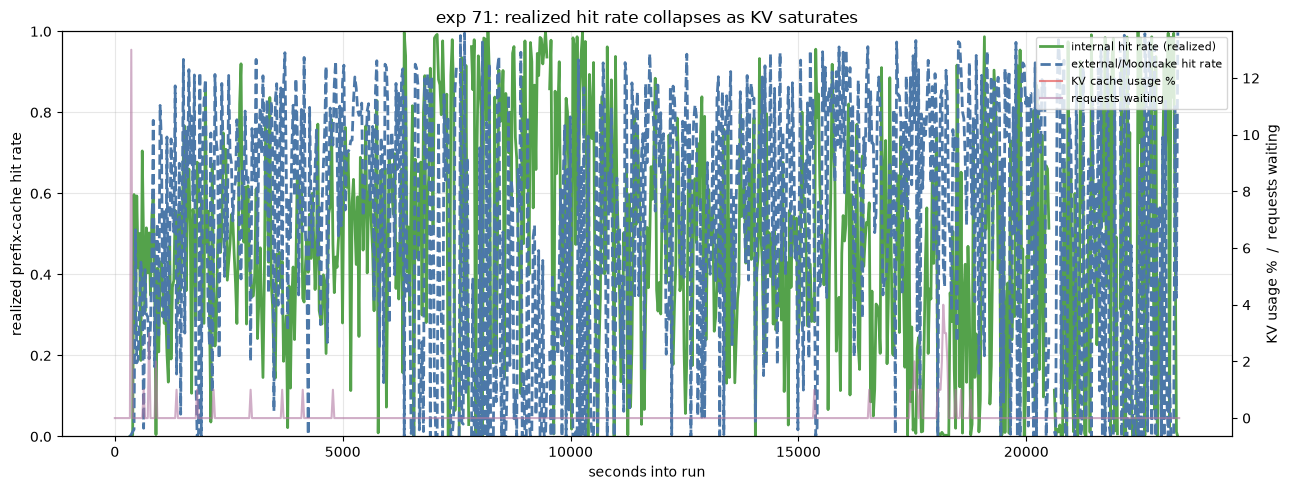

fleet-weighted realized hit rate: internal=0.286  external=0.626


In [11]:
from experiment_analysis import load_experiment_prom_samples

prom = load_experiment_prom_samples(exp_id=EXP_ID, experiments_root=EXPERIMENTS_ROOT)
print("prom samples:", prom.shape, "| cols:", [c for c in prom.columns][:20])


def _fleet_timeseries(prom):
    """Per-tick fleet aggregate: sum rate numerators/denominators across pods,
    then derive hit rate so it is properly request-weighted (not a mean of ratios)."""
    if prom.empty or "ts" not in prom:
        return pd.DataFrame()
    g = prom.groupby("ts")

    def s(col):
        return g[col].sum() if col in prom.columns else pd.Series(0.0, index=g.size().index)

    def m(col):
        return g[col].mean() if col in prom.columns else pd.Series(np.nan, index=g.size().index)

    out = pd.DataFrame({
        "int_hits": s("prefix_cache_hits_per_sec"),
        "int_q": s("prefix_cache_queries_per_sec"),
        "ext_hits": s("ext_prefix_cache_hits_per_sec"),
        "ext_q": s("ext_prefix_cache_queries_per_sec"),
        "kv_usage": m("kv_cache_usage_perc"),
        "waiting": s("requests_waiting"),
        "running": s("requests_running"),
        "preempt": s("preemptions_per_sec"),
    }).reset_index()
    out["internal_hit_rate"] = out["int_hits"] / out["int_q"].replace(0, np.nan)
    out["external_hit_rate"] = out["ext_hits"] / out["ext_q"].replace(0, np.nan)
    # kv_usage may be a fraction (0-1) or percent (0-100); normalise to %
    if out["kv_usage"].max() is not np.nan and out["kv_usage"].max() <= 1.5:
        out["kv_usage"] = out["kv_usage"] * 100.0
    return out


fleet = _fleet_timeseries(prom)
if fleet.empty:
    print("No metrics.jsonl for this experiment - skip §6 (run with metrics enabled).")
else:
    t = pd.to_datetime(fleet["ts"])
    t0 = t.min()
    elapsed = (t - t0).dt.total_seconds()

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(elapsed, fleet["internal_hit_rate"], color="#54A24B", lw=2, label="internal hit rate (realized)")
    if fleet["external_hit_rate"].notna().any():
        ax1.plot(elapsed, fleet["external_hit_rate"], color="#4C78A8", lw=2, ls="--", label="external/Mooncake hit rate")
    ax1.set_ylabel("realized prefix-cache hit rate")
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("seconds into run")

    ax2 = ax1.twinx()
    ax2.plot(elapsed, fleet["kv_usage"], color="#E45756", alpha=0.7, label="KV cache usage %")
    ax2.plot(elapsed, fleet["waiting"], color="#B279A2", alpha=0.6, label="requests waiting")
    ax2.set_ylabel("KV usage %  /  requests waiting")

    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc="upper right", fontsize=8)
    ax1.set_title(f"exp {EXP_ID}: realized hit rate collapses as KV saturates")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("fleet-weighted realized hit rate: "
          f"internal={fleet['int_hits'].sum() / max(fleet['int_q'].sum(), 1e-9):.3f}  "
          f"external={fleet['ext_hits'].sum() / max(fleet['ext_q'].sum(), 1e-9):.3f}")

## 7. Nominal vs realized, side by side

Two views that tie the router's promise to the engine's delivery:
- **Over time:** router nominal hit fraction (`kv_hit` from `logs.json`, binned by
  `t0_wall`) vs engine realized internal hit rate. Affinity keeps the green router line
  high; the drop is on the engine side.
- **Per request:** `matched_tokens` (how much prefix the router promised) vs TTFT, split by
  early/late in the run. If hits were realized, more matched tokens → lower TTFT. Under the
  collapse, the promised prefix stops paying off (TTFT stays high despite a big match).

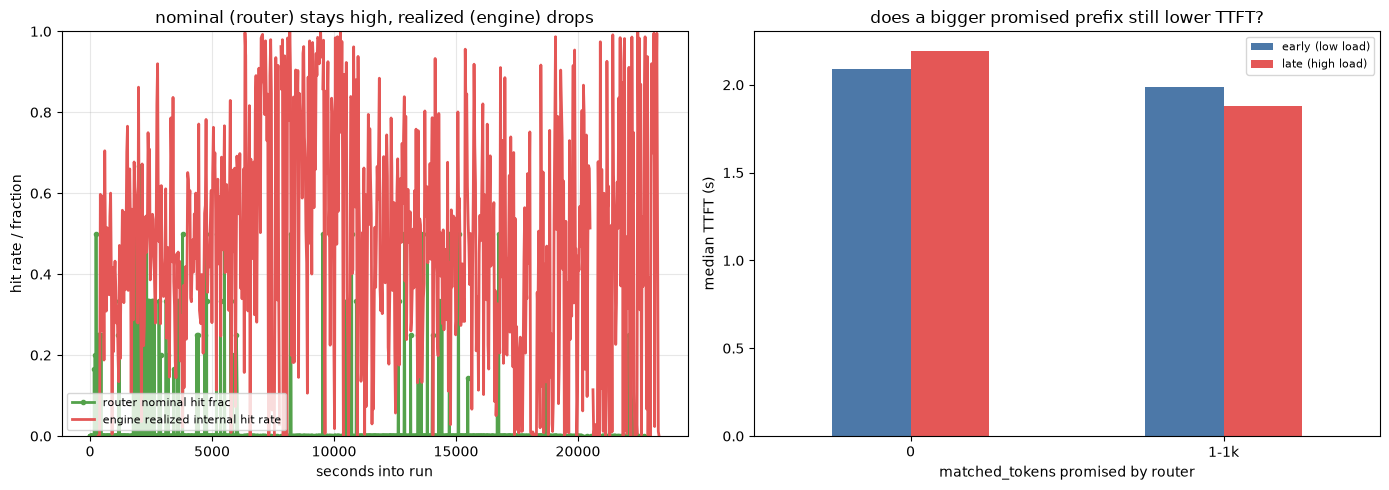

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) nominal (router) vs realized (engine) over time ---
r = df[df["t0_wall"].notna()].copy()
if len(r) and r["kv_hit"].notna().any():
    r["rel_s"] = r["t0_wall"] - r["t0_wall"].min()
    bin_s = 5.0
    r["bin"] = (r["rel_s"] // bin_s) * bin_s
    nominal = r.groupby("bin").agg(
        nominal_hit_frac=("kv_hit", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        n=("req_id", "size"),
    ).reset_index()
    nominal = nominal[nominal["n"] >= 2]
    ax[0].plot(nominal["bin"], nominal["nominal_hit_frac"], color="#54A24B", lw=2,
               marker="o", ms=3, label="router nominal hit frac")
if not fleet.empty:
    fe = (pd.to_datetime(fleet["ts"]) - pd.to_datetime(fleet["ts"]).min()).dt.total_seconds()
    ax[0].plot(fe, fleet["internal_hit_rate"], color="#E45756", lw=2,
               label="engine realized internal hit rate")
ax[0].set_xlabel("seconds into run")
ax[0].set_ylabel("hit rate / fraction")
ax[0].set_ylim(0, 1)
ax[0].set_title("nominal (router) stays high, realized (engine) drops")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

# --- (b) matched_tokens promised vs TTFT paid, early vs late ---
m = df[df["matched_tokens"].notna() & df["ttft_s"].notna() & df["t0_wall"].notna()].copy()
if len(m) > 10:
    half = m["t0_wall"].median()
    m["phase"] = np.where(m["t0_wall"] <= half, "early (low load)", "late (high load)")
    edges = [-1, 0, 1000, 5000, 20000, 1e12]
    labels = ["0", "1-1k", "1k-5k", "5k-20k", ">20k"]
    m["mt_bucket"] = pd.cut(m["matched_tokens"].fillna(0), bins=edges, labels=labels)
    piv = m.groupby(["mt_bucket", "phase"], observed=True)["ttft_s"].median().unstack()
    piv.plot(kind="bar", ax=ax[1], color={"early (low load)": "#4C78A8", "late (high load)": "#E45756"})
    ax[1].set_xlabel("matched_tokens promised by router")
    ax[1].set_ylabel("median TTFT (s)")
    ax[1].set_title("does a bigger promised prefix still lower TTFT?")
    ax[1].tick_params(axis="x", rotation=0)
    ax[1].legend(title="", fontsize=8)
else:
    ax[1].text(0.5, 0.5, "not enough matched_tokens+ttft data", ha="center", va="center")

plt.tight_layout()
plt.show()

## 8. Per-request KV-hit fraction over time (find the sudden drop)

Zooms into the router-reported `kv_hit` fraction across the run at fine time
resolution, with a rolling average, and **auto-detects the drop**: it computes an
early-run baseline and flags (a) the steepest bin-to-bin fall and (b) the first time
the rolling hit fraction stays below `DROP_FRAC x baseline`. The request rate is
overlaid so you can see whether the drop coincides with the load ramp.

Knobs: `BIN_S` (time bin width), `ROLL` (rolling window in bins), `DROP_FRAC`
(what counts as "collapsed" relative to baseline).

baseline hit frac (first 10 bins): 0.000
threshold for 'collapsed' (0.6x baseline): 0.000
steepest drop at ~10306s
no sustained collapse detected at current DROP_FRAC


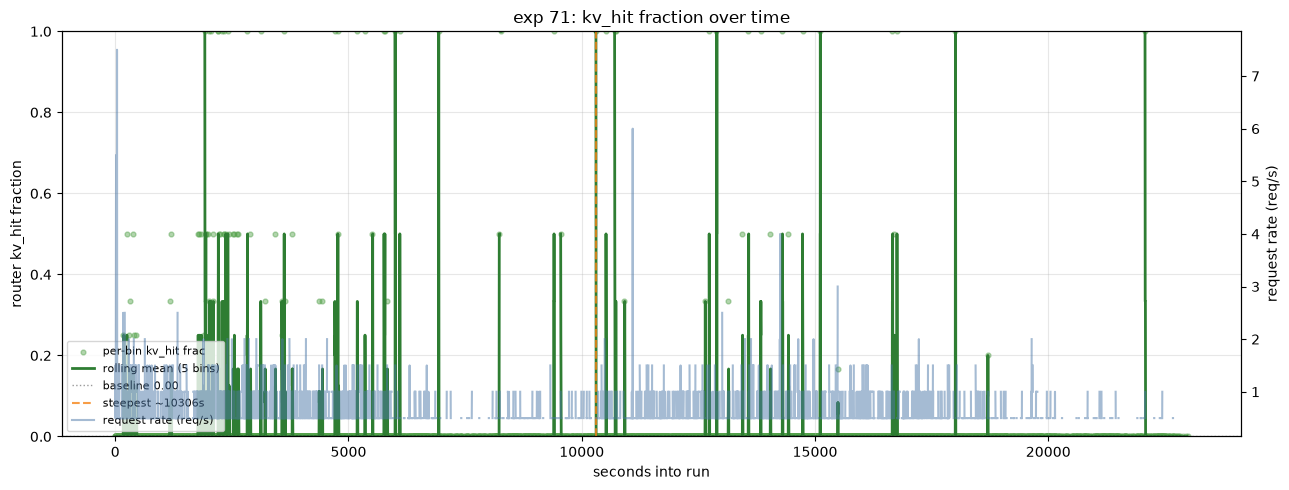

In [13]:
BIN_S = 2.0        # time-bin width (s)
ROLL = 5           # rolling window (# bins)
DROP_FRAC = 0.6    # "collapsed" = rolling hit frac below this * baseline
BASELINE_BINS = 10 # # of early bins used for the baseline

d = df[df["t0_wall"].notna()].copy()
if not len(d) or not d["kv_hit"].notna().any():
    print("No t0_wall / kv_hit in logs.json — cannot build the time series.")
else:
    d["rel_s"] = d["t0_wall"] - d["t0_wall"].min()
    d["kv_hit_b"] = d["kv_hit"].fillna(False).astype(bool)
    d["bin"] = (d["rel_s"] // BIN_S) * BIN_S

    ts = d.groupby("bin").agg(
        hit_frac=("kv_hit_b", "mean"),
        n=("req_id", "size"),
        matched_mean=("matched_tokens", "mean"),
    ).reset_index()
    # reindex onto a regular grid so gaps don't hide a drop
    grid = np.arange(0, ts["bin"].max() + BIN_S, BIN_S)
    ts = ts.set_index("bin").reindex(grid)
    ts.index.name = "bin"
    ts = ts.reset_index()
    ts["req_per_s"] = ts["n"] / BIN_S
    ts["roll"] = ts["hit_frac"].rolling(ROLL, min_periods=1).mean()

    baseline = ts["hit_frac"].dropna().iloc[:BASELINE_BINS].mean()

    # (a) steepest single-bin fall in the rolling series
    diff = ts["roll"].diff()
    steep_i = diff.idxmin() if diff.notna().any() else None
    steep_t = ts["bin"].iloc[steep_i] if steep_i is not None else None

    # (b) first sustained drop below DROP_FRAC * baseline (2 consecutive bins)
    thr = DROP_FRAC * baseline
    below = ts["roll"] < thr
    drop_t = None
    for i in range(len(below) - 1):
        if bool(below.iloc[i]) and bool(below.iloc[i + 1]):
            drop_t = ts["bin"].iloc[i]
            break

    after = ts.loc[ts["bin"] >= drop_t, "hit_frac"].mean() if drop_t is not None else None
    print(f"baseline hit frac (first {BASELINE_BINS} bins): {baseline:.3f}")
    print(f"threshold for 'collapsed' ({DROP_FRAC}x baseline): {thr:.3f}")
    print(f"steepest drop at ~{steep_t:.0f}s" if steep_t is not None else "steepest drop: n/a")
    if drop_t is not None:
        print(f"sustained collapse begins at ~{drop_t:.0f}s "
              f"(mean hit frac after: {after:.3f}, so {baseline:.3f} -> {after:.3f})")
    else:
        print("no sustained collapse detected at current DROP_FRAC")

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.scatter(ts["bin"], ts["hit_frac"], s=12, color="#54A24B", alpha=0.45, label="per-bin kv_hit frac")
    ax1.plot(ts["bin"], ts["roll"], color="#2E7D32", lw=2, label=f"rolling mean ({ROLL} bins)")
    ax1.axhline(baseline, color="#999999", ls=":", lw=1, label=f"baseline {baseline:.2f}")
    if drop_t is not None:
        ax1.axvline(drop_t, color="#E45756", ls="--", lw=2, label=f"collapse ~{drop_t:.0f}s")
    if steep_t is not None and (drop_t is None or abs(steep_t - drop_t) > BIN_S):
        ax1.axvline(steep_t, color="#F58518", ls="--", lw=1.5, alpha=0.8, label=f"steepest ~{steep_t:.0f}s")
    ax1.set_ylabel("router kv_hit fraction")
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("seconds into run")

    ax2 = ax1.twinx()
    ax2.plot(ts["bin"], ts["req_per_s"], color="#4C78A8", alpha=0.5, label="request rate (req/s)")
    ax2.set_ylabel("request rate (req/s)")

    l1, la1 = ax1.get_legend_handles_labels()
    l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, la1 + la2, loc="lower left", fontsize=8)
    ax1.set_title(f"exp {EXP_ID}: kv_hit fraction over time")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## What to send back

Screenshot these for the decision:
1. The **summary JSON** from §1 (`sticky_frac`, `avg_distinct_endpoints`, `overall_kv_hit_frac`).
2. §2 histogram (pod spread per conversation).
3. §3 per-pod table + bars (load balance + per-pod hit fraction).
4. §4 KV-hit and TTFT vs turn.
5. §5 sticky-vs-spread table (if any spread existed).
6. §6 realized hit rate vs KV-usage/waiting over time.
7. §7 nominal-vs-realized (both plots).
8. §8 per-request kv_hit fraction over time + the detected drop time.

Rough read:
- `sticky_frac >= ~0.98` and `avg_distinct_endpoints ~1.0` → hard affinity is doing its job.
- KV-hit fraction climbing after turn 0 and TTFT dropping after turn 0 → stickiness is turning into real prefix reuse.
- If stickiness is high but per-pod load is very skewed (`max/mean` large), that is the thing to watch, not stickiness itself.

Why the hit rate drops despite having hits (§6–§7):
- If the **router nominal** line (green, §7a) stays high but the **engine realized** line
  (red) falls, the hits are being *promised and then evicted* — not a routing/affinity bug.
- The realized drop lining up with `kv_cache_usage_perc` hitting ~90%+ and `requests_waiting`
  climbing (§6) is the saturation/eviction signature — the GPU KV has no room to keep the
  prefix blocks, so LMCache reloads them (the NDS thrash from the log analysis).
- In §7b, if `late (high load)` TTFT no longer falls as `matched_tokens` grows, the promised
  prefix stopped paying off — the concrete "we have hits but they don't help" evidence.
- Fix direction is the same as the config change: bigger local cache + capped concurrency so
  the engine can *retain* the prefix the router keeps sending it.

## 9. Machine-readable dump (paste this back for analysis)

Run this last. It **recomputes every number** from `df` (and the engine metrics from
§6 if you ran it) and prints one JSON block. Copy the whole block between the marker
lines and paste it back into chat — it contains the stickiness summary, per-pod table,
per-turn table, sticky-vs-spread, the full per-bin `kv_hit` time series + detected
drop, and the engine realized hit-rate/KV-usage/waiting series. No plots needed.

## 7. Do "single-turn" conversations actually share prefix-cache blocks?

Suspicion: the router may be receiving requests that **share a KV prefix** but treating
them as separate **single-turn** conversations (i.e. `affinity_key` doesn't group them),
so prefix-cache reuse is left on the table.

This cell re-reads the raw `block_hashes` from `logs.json` (they're not in `_FIELDS`) and,
for every request classified as single-turn, computes the **longest common leading
block-hash prefix (LCP)** it shares with *any other* request in the run. A single-turn
request with a large shared prefix but `kv_hits_len == 0` is exactly the smoking gun:
the prefix existed elsewhere, but the router neither grouped it (affinity) nor credited
it (KV-aware). We also check whether the sharer is a **different `group`** (different
affinity key) and whether it landed on the **same endpoint**.

single-turn requests with >=1 full block : 796
  share a leading prefix (>=1 block) w/ another req : 716 (89.9%)
  shared-prefix blocks   p50=6 p90=84 max=253 (~768 tok median)
  ...but router logged kv_hits_len==0        : 714/716 (99.7%)   <-- reuse the router missed
  ...sharer is a DIFFERENT affinity group    : 716/716 (100.0%)   <-- not grouped as same conversation
  ...sharer landed on the SAME endpoint      : 341/716 (47.6%)

Worst offenders (largest shared prefix, router credited nothing):


,req_id,endpoint_id,partner_endpoint,diff_group,shared_prefix_blocks,shared_prefix_tokens,prompt_tokens,kv_hits_len
4134,47043aa500c04650b32d3ffc95177961,vllm-minimax-m2-1,vllm-minimax-m2-1,True,253,32384,32572,0
4331,3e4ba42b2af641b6b52e5b7be8688f81,vllm-minimax-m2-1,vllm-minimax-m2-1,True,253,32384,32807,0
4097,3850dd8b2a67436c842ac440b2b248c9,vllm-minimax-m2-0,vllm-minimax-m2-1,True,252,32256,32411,0
3264,45aa7a83b2324680844d99d5a3060299,vllm-minimax-m2-1,vllm-minimax-m2-1,True,230,29440,29602,0
3223,ac929dd8cd3d41faaafe0d48ea063a61,vllm-minimax-m2-0,vllm-minimax-m2-0,True,229,29312,29389,0
3178,dc00b8bc2eee42afa65b61dde64f8d15,vllm-minimax-m2-0,vllm-minimax-m2-0,True,226,28928,29035,0
3152,e52bc510bf8f4cd0a78d29a0fd4a53cd,vllm-minimax-m2-0,vllm-minimax-m2-0,True,225,28800,28938,0
4761,28c0b67418df47db997d6dce30de45b9,vllm-minimax-m2-1,vllm-minimax-m2-0,True,207,26496,34824,0
981,c713e1ff9989438a99fe53e27d4c6bd3,vllm-minimax-m2-0,vllm-minimax-m2-1,True,207,26496,42668,0
5218,8f47416655844f3a904219fc121df2a4,vllm-minimax-m2-0,vllm-minimax-m2-0,True,205,26240,26451,0


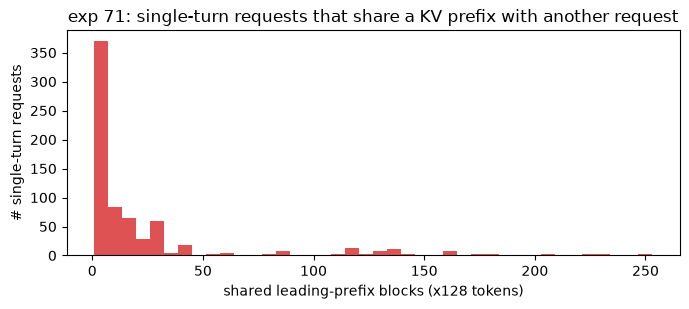

In [14]:
# --- §7: single-turn conversations that nonetheless share a prefix-cache prefix ---
# block_hashes are NOT in _FIELDS, so pull them straight from the raw log.
_bh_path = Path(EXPERIMENTS_ROOT) / str(EXP_ID) / "logs.json"
bh_by_req = {}
with _bh_path.open("r", encoding="utf-8") as f:
    for _line in f:
        _line = _line.strip()
        if not _line:
            continue
        _r = json.loads(_line)
        if _r.get("send_failed"):
            continue
        bh_by_req[_r["req_id"]] = tuple(_r.get("block_hashes") or [])

BS = 128  # KV_BLOCK_SIZE (must match the router / vLLM --block-size)

d = df.copy()
d["block_hashes"] = d["req_id"].map(bh_by_req)
d["n_blocks"] = d["block_hashes"].map(lambda x: len(x) if x else 0)
d["group_size"] = d.groupby("group")["req_id"].transform("size")
d["is_single_turn"] = d["group_size"] == 1

if d["n_blocks"].sum() == 0:
    print("No block_hashes in this log (router_log_block_hashes was off) - cannot run §7.")
else:
    # only requests with >=1 full block can share a prefix
    cand = d[d["n_blocks"] > 0].reset_index(drop=True)
    order = cand["block_hashes"].tolist()
    rids  = cand["req_id"].tolist()
    eps   = cand["endpoint_id"].tolist()
    grps  = cand["group"].tolist()

    def _lcp(a, b):
        n = 0
        for x, y in zip(a, b):
            if x == y:
                n += 1
            else:
                break
        return n

    # max LCP for a sequence is always achieved with a lexicographic neighbour,
    # so sort once (O(n log n)) and compare adjacent pairs.
    srt = sorted(range(len(order)), key=lambda i: order[i])
    best = [0] * len(order)
    partner = [None] * len(order)
    for k in range(1, len(srt)):
        i, j = srt[k - 1], srt[k]
        l = _lcp(order[i], order[j])
        if l > best[i]:
            best[i], partner[i] = l, j
        if l > best[j]:
            best[j], partner[j] = l, i

    cand["shared_prefix_blocks"] = best
    cand["shared_prefix_tokens"] = [b * BS for b in best]
    cand["partner_req"]      = [rids[partner[i]] if partner[i] is not None else None for i in range(len(order))]
    cand["partner_endpoint"] = [eps[partner[i]]  if partner[i] is not None else None for i in range(len(order))]
    cand["partner_group"]    = [grps[partner[i]] if partner[i] is not None else None for i in range(len(order))]
    cand["same_endpoint"]    = cand["endpoint_id"] == cand["partner_endpoint"]
    cand["diff_group"]       = cand["group"] != cand["partner_group"]

    st = cand[cand["is_single_turn"]].copy()
    shared = st[st["shared_prefix_blocks"] > 0].copy()

    print(f"single-turn requests with >=1 full block : {len(st)}")
    if len(st):
        frac = len(shared) / len(st)
        print(f"  share a leading prefix (>=1 block) w/ another req : {len(shared)} ({frac:.1%})")
    if len(shared):
        missed = int((shared["kv_hits_len"].fillna(0) == 0).sum())
        diffg  = int(shared["diff_group"].sum())
        sameep = int(shared["same_endpoint"].sum())
        print(f"  shared-prefix blocks   p50={shared['shared_prefix_blocks'].median():.0f} "
              f"p90={shared['shared_prefix_blocks'].quantile(.9):.0f} "
              f"max={shared['shared_prefix_blocks'].max():.0f} "
              f"(~{int(shared['shared_prefix_tokens'].median())} tok median)")
        print(f"  ...but router logged kv_hits_len==0        : {missed}/{len(shared)} "
              f"({missed/len(shared):.1%})   <-- reuse the router missed")
        print(f"  ...sharer is a DIFFERENT affinity group    : {diffg}/{len(shared)} "
              f"({diffg/len(shared):.1%})   <-- not grouped as same conversation")
        print(f"  ...sharer landed on the SAME endpoint      : {sameep}/{len(shared)} "
              f"({sameep/len(shared):.1%})")

        cols = ["req_id", "endpoint_id", "partner_endpoint", "diff_group",
                "shared_prefix_blocks", "shared_prefix_tokens",
                "prompt_tokens", "kv_hits_len"]
        print("\nWorst offenders (largest shared prefix, router credited nothing):")
        worst = (shared[shared["kv_hits_len"].fillna(0) == 0]
                 .sort_values("shared_prefix_blocks", ascending=False)
                 .head(15)[cols])
        try:
            from IPython.display import display
            display(worst)
        except Exception:
            print(worst.to_string(index=False))

        fig, ax = plt.subplots(figsize=(7, 3.2))
        ax.hist(shared["shared_prefix_blocks"], bins=40, color="tab:red", alpha=0.8)
        ax.set_xlabel(f"shared leading-prefix blocks (x{BS} tokens)")
        ax.set_ylabel("# single-turn requests")
        ax.set_title(f"exp {EXP_ID}: single-turn requests that share a KV prefix with another request")
        plt.tight_layout(); plt.show()
    else:
        print("  No single-turn request shares a leading block-hash prefix with any other "
              "request -> prefix reuse genuinely absent (not a grouping/routing miss).")

## 8. How much traffic is *really* key-affinity?

Affinity only does something when the **same key recurs** (a real multi-turn chat that
re-sends the identical opening). This cell reconstructs, retrospectively, how the run
splits:

- **single-turn** groups (key seen once) - affinity has nothing to stick to; these fall
  through to the fallback load-balancer.
- **multi-turn** groups (key seen >=2x) - affinity-eligible.
- of the affinity-eligible **repeat turns** (turn 2, 3, ...), how many actually landed on
  the **same endpoint** as turn 1 (affinity honored) vs scattered.

Reported by both **request count** and **prompt-token share**, so you can see how much of
the real workload affinity is actually covering.

total: 5,979 requests | 1,372 distinct keys | 324,475,010 prompt tokens

by request count:
  single-turn (key seen 1x)   : 805 (13.5%)
  multi-turn  (key seen >=2x)  : 5,174 (86.5%)
by prompt-token share:
  single-turn                  : 7,724,061 (2.4%)
  multi-turn                   : 316,750,949 (97.6%)

groups: 805 single-turn  |  567 multi-turn (41.3% of keys)

affinity-eligible repeat turns (turn 2,3,...): 4,607 (77.1%) of all requests
  landed on SAME endpoint as turn 1 (affinity honored): 3876/4607 (84.1%)
  multi-turn groups fully sticky (1 endpoint end-to-end): 565/567 (99.6%)


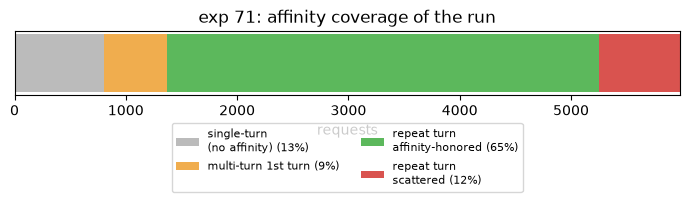

In [15]:
# --- §8: how much of the run is really key-affinity? ---
a = df.copy()

# grouping key; rows with no key become their own singleton (unique fallback)
a["gkey"] = a["group"]
_na = a["gkey"].isna()
a.loc[_na, "gkey"] = "req:" + a.loc[_na, "req_id"].astype(str)

a["gsize"] = a.groupby("gkey")["req_id"].transform("size")
a["ptok"] = pd.to_numeric(a["prompt_tokens"], errors="coerce").fillna(0)

tot_req = len(a)
tot_tok = a["ptok"].sum()

single = a[a["gsize"] == 1]
multi  = a[a["gsize"] >= 2]

n_groups        = a["gkey"].nunique()
n_single_groups = int((a.groupby("gkey")["req_id"].size() == 1).sum())
n_multi_groups  = n_groups - n_single_groups

def _pct(x, tot):
    return f"{x:,} ({x/tot:.1%})" if tot else f"{x:,}"

print(f"total: {tot_req:,} requests | {n_groups:,} distinct keys | {int(tot_tok):,} prompt tokens\n")
print("by request count:")
print(f"  single-turn (key seen 1x)   : {_pct(len(single), tot_req)}")
print(f"  multi-turn  (key seen >=2x)  : {_pct(len(multi),  tot_req)}")
print("by prompt-token share:")
print(f"  single-turn                  : {_pct(int(single['ptok'].sum()), int(tot_tok))}")
print(f"  multi-turn                   : {_pct(int(multi['ptok'].sum()),  int(tot_tok))}")
print(f"\ngroups: {n_single_groups:,} single-turn  |  {n_multi_groups:,} multi-turn "
      f"({n_multi_groups/max(n_groups,1):.1%} of keys)")

# --- did affinity actually hold for the repeat turns? ---
a2 = a.sort_values("t0_wall")
a2["occ"] = a2.groupby("gkey").cumcount()             # 0 = first turn of the key
first_ep = a2[a2["occ"] == 0].set_index("gkey")["endpoint_id"]
a2["first_ep"] = a2["gkey"].map(first_ep)

repeat = a2[a2["occ"] > 0]                            # turns that COULD benefit from affinity
if len(repeat):
    honored = int((repeat["endpoint_id"] == repeat["first_ep"]).sum())
    print(f"\naffinity-eligible repeat turns (turn 2,3,...): {_pct(len(repeat), tot_req)} of all requests")
    print(f"  landed on SAME endpoint as turn 1 (affinity honored): "
          f"{honored}/{len(repeat)} ({honored/len(repeat):.1%})")

    # per multi-turn group: was the whole conversation kept on one endpoint?
    mg = a.groupby("gkey").agg(n=("req_id", "size"), n_ep=("endpoint_id", "nunique"))
    mg = mg[mg["n"] >= 2]
    fully = int((mg["n_ep"] == 1).sum())
    print(f"  multi-turn groups fully sticky (1 endpoint end-to-end): "
          f"{fully}/{len(mg)} ({fully/max(len(mg),1):.1%})")
else:
    print("\nNo repeat turns at all -> every key is unique -> affinity is inert for this run.")

# compact visual
fig, ax = plt.subplots(figsize=(7, 2.6))
seg = {
    "single-turn\n(no affinity)": len(single),
    "multi-turn 1st turn": len(multi) - len(repeat),
    "repeat turn\naffinity-honored": int((repeat["endpoint_id"] == repeat["first_ep"]).sum()) if len(repeat) else 0,
    "repeat turn\nscattered": (len(repeat) - int((repeat["endpoint_id"] == repeat["first_ep"]).sum())) if len(repeat) else 0,
}
colors = ["#bbbbbb", "#f0ad4e", "#5cb85c", "#d9534f"]
left = 0
for (lbl, val), c in zip(seg.items(), colors):
    if val <= 0:
        continue
    ax.barh(0, val, left=left, color=c, label=f"{lbl} ({val/tot_req:.0%})")
    left += val
ax.set_yticks([]); ax.set_xlim(0, tot_req)
ax.set_xlabel("requests")
ax.set_title(f"exp {EXP_ID}: affinity coverage of the run")
ax.legend(ncol=2, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.35))
plt.tight_layout(); plt.show()

## 9. `kv_hit` rate over time

How often the router logged a KV hit (`kv_hit == True`), binned over the run. Green line is
the per-bin hit rate (dashed = run average); blue bars are request volume so you can tell
whether dips line up with load spikes. Also split by turn type (single-turn vs multi-turn
repeat turns) to see where the hits actually come from.

overall kv_hit: 1.5%  (91/5,979 requests)
  single-turn requests        : 0.2%
  multi-turn 1st turn          : 0.7%
  multi-turn repeat turns      : 1.8%   <-- where affinity should pay off


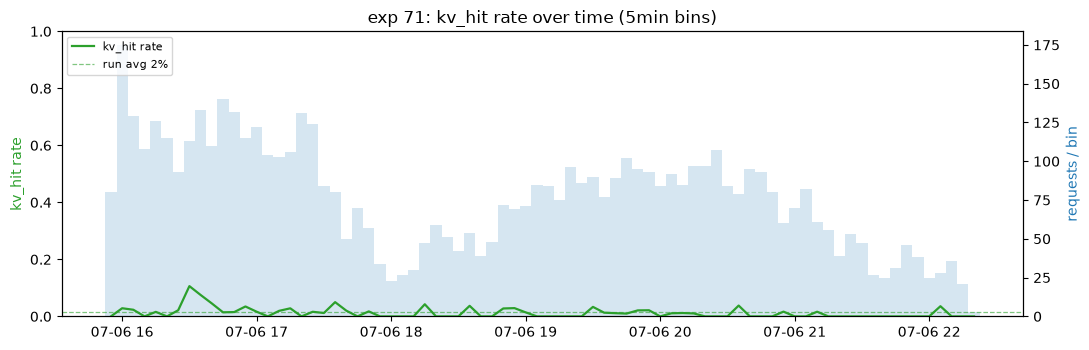

In [16]:
# --- §9: kv_hit rate over time ---
k = df[df["kv_hit"].notna()].copy()
k["kv_hit"] = k["kv_hit"].astype(bool)

overall = k["kv_hit"].mean()
print(f"overall kv_hit: {overall:.1%}  ({int(k['kv_hit'].sum()):,}/{len(k):,} requests)")

# split by turn type (reuse the grouping from earlier sections)
k["gkey"] = k["group"]
_na = k["gkey"].isna()
k.loc[_na, "gkey"] = "req:" + k.loc[_na, "req_id"].astype(str)
k["gsize"] = k.groupby("gkey")["req_id"].transform("size")
ks = k.sort_values("t0_wall")
ks["occ"] = ks.groupby("gkey").cumcount()
k = k.merge(ks[["req_id", "occ"]], on="req_id", how="left")

single_hit  = k.loc[k["gsize"] == 1, "kv_hit"].mean()
first_hit   = k.loc[(k["gsize"] >= 2) & (k["occ"] == 0), "kv_hit"].mean()
repeat_hit  = k.loc[(k["gsize"] >= 2) & (k["occ"] > 0), "kv_hit"].mean()
print(f"  single-turn requests        : {single_hit:.1%}")
print(f"  multi-turn 1st turn          : {first_hit:.1%}")
print(f"  multi-turn repeat turns      : {repeat_hit:.1%}   <-- where affinity should pay off")

OFF = globals().get("LOCAL_OFFSET_H", 8)
k["t"] = pd.to_datetime(k["t0_wall"], unit="s") + pd.Timedelta(hours=OFF)
k = k.dropna(subset=["t"]).sort_values("t")

BIN = "5min"
g = k.set_index("t").groupby(pd.Grouper(freq=BIN))
ts = g["kv_hit"].agg(["mean", "size"]).rename(columns={"mean": "hit_rate", "size": "n"})
ts = ts[ts["n"] > 0]

fig, ax1 = plt.subplots(figsize=(11, 3.6))
w = pd.Timedelta(BIN) / pd.Timedelta(days=1)
ax2 = ax1.twinx()
ax2.bar(ts.index, ts["n"], width=w, color="tab:blue", alpha=0.18, zorder=1)
ax2.set_ylabel("requests / bin", color="tab:blue")
ax1.plot(ts.index, ts["hit_rate"], color="tab:green", lw=1.6, zorder=3, label="kv_hit rate")
ax1.axhline(overall, color="tab:green", ls="--", lw=0.9, alpha=0.6, zorder=2,
            label=f"run avg {overall:.0%}")
ax1.set_ylabel("kv_hit rate", color="tab:green")
ax1.set_ylim(0, 1)
ax1.set_zorder(ax2.get_zorder() + 1); ax1.patch.set_visible(False)
ax1.set_title(f"exp {EXP_ID}: kv_hit rate over time ({BIN} bins)")
ax1.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()